<a href="https://colab.research.google.com/github/nbrav/NeuroAgents/blob/main/notebooks/motornet_eprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a network

The purpose of this notebook is to create a network to control an effector, and to train it to perform a task through the optimization process. We will also briefly cover how to save and re-load a network.

For how to build an effector and environment from scratch, feel free to look up the `1-build-effector.ipynb` and `3-environments.ipynb` notebooks.

Let's start by importing what we need.


In [ ]:
print ("Hello world")

Hello world


In [ ]:
import os
import sys
import json
import numpy as np
import torch as th
import matplotlib.pyplot as plt

motornet_in_cwd = os.path.exists("MotorNet") or os.path.exists("motornet")
colab_env = 'google.colab' in str(get_ipython()) if hasattr(__builtins__,'__IPYTHON__') else False
colab_initialized = True if motornet_in_cwd else False

if colab_env and not colab_initialized:
  !pip install gymnasium>=2.8
  !pip install git+https://github.com/motornet-org/MotorNet
  # !pip install git+https://github.com/OlivierCodol/MotorNet@pytorch
  sys.path.append('MotorNet')
  print("Running cell using COLAB initialization...")
elif colab_env and colab_initialized:
  print("Already initialized using COLAB initialization.")
else:
  paths = [p for p in sys.path if os.path.exists(p)]
  local_initialized = True if [p for p in paths if "MotorNet" in os.listdir(p)] else False
  if local_initialized:
    %load_ext autoreload
    %autoreload 2
    print("Already initialized using LOCAL initialization.")
  else:
    for _cand in ("../MotorNet", "MotorNet"):
      if os.path.isdir(_cand):
        sys.path.insert(0, os.path.abspath(_cand)); break
    import motornet  # noqa: F401  (this repo: the MotorNet submodule is importable directly)
    %load_ext autoreload
    %autoreload 2
    print("Running cell using LOCAL initialization...")

  Cloning https://github.com/motornet-org/MotorNet to /tmp/pip-req-build-gt7cza7y
  Running command git clone --filter=blob:none --quiet https://github.com/motornet-org/MotorNet /tmp/pip-req-build-gt7cza7y
  Resolved https://github.com/motornet-org/MotorNet to commit ad606747396611689136d9e3a915c80500efeebe
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for motornet: filename=motornet-0.3.0-py3-none-any.whl size=52718 sha256=a60ab938a7338ee9a7b7a069e850f55ace4e28c6598b48fa21d9556ecf5efdd7
  Stored in directory: /tmp/pip-ephem-wheel-cache-rlhy3_cb/wheels/e8/68/4a/b5a5d5f622b3850205d1f1512c78078f0e9423954ca9f3a27b
Successfully built motornet
Running cell using COLAB initialization...


In [ ]:
import motornet as mn

print('All packages imported.')
print('pytorch version: ' + th.__version__)
print('numpy version: ' + np.__version__)
print('motornet version: ' + mn.__version__)

All packages imported.
pytorch version: 2.11.0+cpu
numpy version: 2.0.2
motornet version: 0.3.0



# I. Introduction

Since the purpose of this notebook is not to show how to build an effector or an environment, we will use a pre-built effector and environment that comes with the `motornet` toolbox. This is a 4-muscles point mass plant, with `ReluMuscle` actuators, and a simple random-to-random position reaching task.

Generally speaking, the objects we create follow the hierarchical structure illustrated below.




<img src="https://github.com/OlivierCodol/MotorNet/blob/master/examples/img/hierarchy.png?raw=1" alt="drawing" width="500"/>


# II. Building the model

## II. 1. `Effector` and `Environment` instances.
All the elements below take from previous tutorials, so we are just repeating them here.

Note that we specify the maximum duration of an episode to be 1 sec. We set this up explicitly here, but this is actually the default if no value is provided.

In [ ]:
effector = mn.effector.ReluPointMass24()
env = mn.environment.RandomTargetReach(effector=effector, max_ep_duration=1.)

## II. 2. Building the network

This step simply reduces to building a `torch.nn.Module` subclass. If you are not sure on how to achieve that, there are many tutorials available online for learning PyTorch basics.

A good and simple model for this kind of task is to have one recurrent layer receiving observation inputs, so the input dimension is the size of the observation vector. Here we specify the recurrent layer to be one layer of 32 Gated Recurrent Units (GRUs). The output layer is a simple fully connected linear layer, with a sigmoid non-linearity.

Note that we initialize the fully connected layer's bias to be `-5`, to ensure we start the training with low output forces and therefore a more stable situation. Also note that the action that should be input into the environment should be bounded from 0 to 1, which the sigmoid guarantees.

In [ ]:
class Policy(th.nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, device):
        super().__init__()
        self.device = device
        self.hidden_dim = hidden_dim
        self.n_layers = 1

        self.gru = th.nn.GRU(input_dim, hidden_dim, 1, batch_first=True)
        self.fc = th.nn.Linear(hidden_dim, output_dim)
        self.sigmoid = th.nn.Sigmoid()

        # the default initialization in torch isn't ideal
        for name, param in self.named_parameters():
            if name == "gru.weight_ih_l0":
                th.nn.init.xavier_uniform_(param)
            elif name == "gru.weight_hh_l0":
                th.nn.init.orthogonal_(param)
            elif name == "gru.bias_ih_l0":
                th.nn.init.zeros_(param)
            elif name == "gru.bias_hh_l0":
                th.nn.init.zeros_(param)
            elif name == "fc.weight":
                th.nn.init.xavier_uniform_(param)
            elif name == "fc.bias":
                th.nn.init.constant_(param, -5.)
            else:
                raise ValueError

        self.to(device)

    def forward(self, x, h0):
        y, h = self.gru(x[:, None, :], h0)
        u = self.sigmoid(self.fc(y)).squeeze(dim=1)
        return u, h

    def init_hidden(self, batch_size):
        weight = next(self.parameters()).data
        hidden = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().to(self.device)
        return hidden

device = th.device("cpu")

policy = Policy(env.observation_space.shape[0], 32, env.n_muscles, device=device)
optimizer = th.optim.Adam(policy.parameters(), lr=10**-3)

We can then train the `Policy` network like we would any PyTorch model. The output of the `Policy` is then passed as input to the `Environment` object using the `Environment.step()` method. The `obs` and `info` ouputs are then collected and used for the loss computation and the backward pass.

Importantly, adding some clipping greatly improves the training process for motor tasks in general.

In [ ]:
batch_size = 32
n_batch = 6000
losses = []
interval = 250

def l1(x, y):
  """L1 loss"""
  return th.mean(th.sum(th.abs(x - y), dim=-1))

for batch in range(n_batch):
  # initialize batch
  h = policy.init_hidden(batch_size=batch_size)
  obs, info = env.reset(options={"batch_size": batch_size})
  terminated = False

  # initial positions and targets
  xy = [info["states"]["fingertip"][:, None, :]]
  tg = [info["goal"][:, None, :]]

  # simulate whole episode
  while not terminated:  # will run until `max_ep_duration` is reached
    action, h = policy(obs, h)
    obs, reward, terminated, truncated, info = env.step(action=action)

    xy.append(info["states"]["fingertip"][:, None, :])  # trajectories
    tg.append(info["goal"][:, None, :])  # targets

  # concatenate into a (batch_size, n_timesteps, xy) tensor
  xy = th.cat(xy, axis=1)
  tg = th.cat(tg, axis=1)
  loss = l1(xy, tg)  # L1 loss on position

  # backward pass & update weights
  optimizer.zero_grad()
  loss.backward()
  th.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.)  # important!
  optimizer.step()
  losses.append(loss.item())

  if (batch % interval == 0) and (batch != 0):
    print("Batch {}/{} Done, mean policy loss: {}".format(batch, n_batch, sum(losses[-interval:])/interval))

Batch 250/6000 Done, mean policy loss: 0.6823256098031998
Batch 500/6000 Done, mean policy loss: 0.2742290591597557
Batch 750/6000 Done, mean policy loss: 0.2070844192504883
Batch 1000/6000 Done, mean policy loss: 0.1804046881198883
Batch 1250/6000 Done, mean policy loss: 0.16460991820693016
Batch 1500/6000 Done, mean policy loss: 0.15411442336440087
Batch 1750/6000 Done, mean policy loss: 0.14744754755496978
Batch 2000/6000 Done, mean policy loss: 0.142021759390831
Batch 2250/6000 Done, mean policy loss: 0.13679210624098778
Batch 2500/6000 Done, mean policy loss: 0.13293800529837607
Batch 2750/6000 Done, mean policy loss: 0.12814378720521927
Batch 3000/6000 Done, mean policy loss: 0.12700807201862335
Batch 3250/6000 Done, mean policy loss: 0.12689339232444763
Batch 3500/6000 Done, mean policy loss: 0.12162153577804566
Batch 3750/6000 Done, mean policy loss: 0.1203802016377449
Batch 4000/6000 Done, mean policy loss: 0.11935523122549058
Batch 4250/6000 Done, mean policy loss: 0.11738905

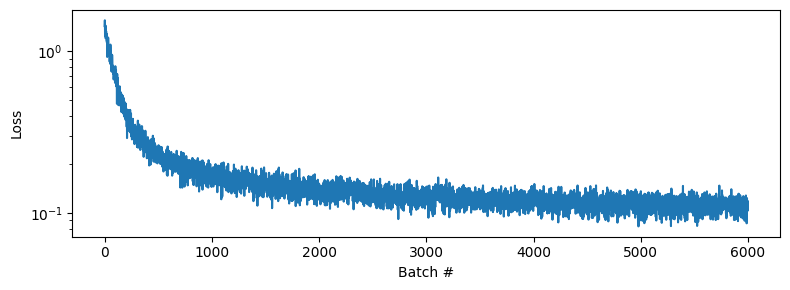

In [ ]:
def plot_training_log(log):
  fig, axs = plt.subplots(1, 1)
  fig.set_tight_layout(True)
  fig.set_size_inches((8, 3))

  axs.semilogy(log)

  axs.set_ylabel("Loss")
  axs.set_xlabel("Batch #")
  plt.show()

plot_training_log(losses)

# III. Evaluating performance

A forward pass on the model (with `deterministic=True`) will yield the evaluation behaviour.

We can plot the resulting states to quickly visualize what the network is doing.


In [ ]:
plotor = mn.plotor.plot_pos_over_time

def plot_simulations(xy, target_xy):
  target_x = target_xy[:, -1, 0]
  target_y = target_xy[:, -1, 1]

  plt.figure(figsize=(10,3))

  plt.subplot(1,2,1)
  plt.ylim([-1.1, 1.1])
  plt.xlim([-1.1, 1.1])
  plotor(axis=plt.gca(), cart_results=xy)
  plt.scatter(target_x, target_y)

  plt.subplot(1,2,2)
  plt.ylim([-2, 2])
  plt.xlim([-2, 2])
  plotor(axis=plt.gca(), cart_results=xy - target_xy)
  plt.axhline(0, c="grey")
  plt.axvline(0, c="grey")
  plt.xlabel("X distance to target")
  plt.ylabel("Y distance to target")
  plt.show()


plot_simulations(xy=th.detach(xy), target_xy=th.detach(tg))


NameError: name 'xy' is not defined

# IV. Saving the model

Next, we can save the network like we would any PyTorch model. We will also save the training history as a `.json` file, and the environment's configuration information for later reference.


In [ ]:
import os

os.makedirs("save", exist_ok=True)

weight_file = os.path.join("save", "weights.pt")
log_file    = os.path.join("save", "log.json")
cfg_file    = os.path.join("save", "cfg.json")

# Save model weights
th.save(policy.state_dict(), weight_file)

# Save training history
with open(log_file, "w") as f:
    json.dump(losses, f)

# Save environment configuration
cfg = env.get_save_config()
with open(cfg_file, "w") as f:
    json.dump(cfg, f)

print("Done.")

Done.


In [ ]:

weight_file = os.path.join("save", "weights")
log_file = os.path.join("save", "log.json")
cfg_file = os.path.join("save", "cfg.json")



In [ ]:

# save model weights
th.save(policy.state_dict(), weight_file)


# save training history (log)
with open(log_file, 'w') as file:
  json.dump(losses, file)


# save environment configuration dictionary
cfg = env.get_save_config()
with open(cfg_file, 'w') as file:
  json.dump(cfg, file)


print("done.")


done.



# V. Loading the model

## V. 1. The configuration file
This file is what the `Environment.get_save_config()` method produces. It contains a dictionary with all the parameter and configuration values used to create the environment. Let's look into its structure quickly.


In [ ]:


with open(cfg_file, 'r') as file:
    cfg = json.load(file)


for k1, v1 in cfg.items():
  if isinstance(v1, dict):
    print(k1 + ":")
    for k2, v2 in v1.items():
      if type(v2) is dict:
        print("\t\t" + k2 + ":")
        for k3, v3 in v2.items():
          print("\t\t\t\t" + k3 + ": ", v3)
      else:
        print("\t\t" + k2 + ": ", v2)
  else:
    print(k1 + ": ", v1)


FileNotFoundError: [Errno 2] No such file or directory: 'save/cfg.json'


## V. 2. Training history

We can use the `.json` file containing the training history to retrieve and plot losses over time.

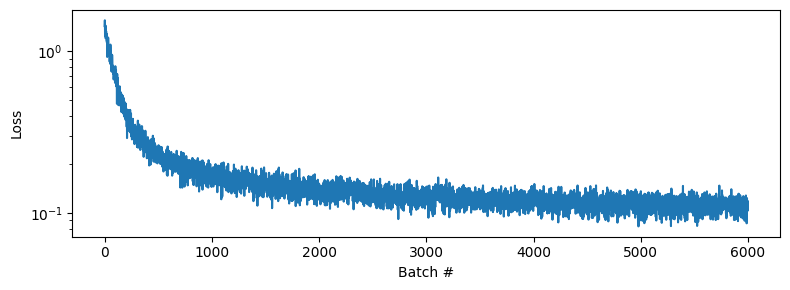

In [ ]:
# retrieve and plot training history
with open(log_file, 'r') as file:
    loaded_training_log = json.load(file)

plot_training_log(log=loaded_training_log)




## V. 3. The model itself

Usually, reloading the model would involve re-creating the same model, and applying the trained weights to that model again. To re-create the model, one could re-use the same function as was used to create the original model (that's what we will do here), or one could exploit the configuration file we saved and re-loaded above to recreate a model exhaustively. The latter method might be more tedious to implement but has the benefit of being more exhaustive on the long run.


In [ ]:

env2 = mn.environment.RandomTargetReach(effector=mn.effector.ReluPointMass24(), max_ep_duration=1.)
policy2 = Policy(env.observation_space.shape[0], 32, env.n_muscles, device=device)

policy2.load_state_dict(th.load(weight_file))


<All keys matched successfully>


# VI. Evaluating the loaded model

We can then do a forward pass the loaded model like we did on the original model.



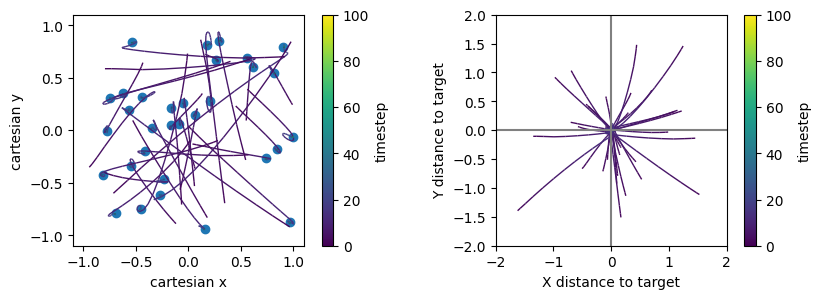

In [ ]:
# ==========
# Evaluation
# ==========

# initialize batch
h = policy.init_hidden(batch_size=batch_size)
obs, info = env.reset(options={"batch_size": batch_size})
terminated = False

# initial positions and targets
xy = [info["states"]["fingertip"][:, None, :]]
tg = [info["goal"][:, None, :]]

# simulate whole episode
while not terminated:  # will run until `max_ep_duration` is reached
  action, h = policy(obs, h)
  obs, reward, terminated, truncated, info = env.step(action=action)

  xy.append(info["states"]["fingertip"][:, None, :])  # trajectories
  tg.append(info["goal"][:, None, :])  # targets

# concatenate into a (batch_size, n_timesteps, xy) tensor
xy = th.detach(th.cat(xy, axis=1))
tg = th.detach(th.cat(tg, axis=1))

plot_simulations(xy=xy, target_xy=tg)


# VII. E-Prop Experiments



In [ ]:
# ============================================================
# MODEL
# ============================================================

class EPropPolicy(th.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, device, dt, tau=0.05):
        super().__init__()

        self.device = th.device(device)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.alpha = float(dt) / float(tau)
        if not 0 < self.alpha <= 1:
            raise ValueError(f"Invalid alpha = dt/tau = {self.alpha}")

        self.w_in = th.nn.Parameter(th.empty(hidden_dim, input_dim))
        self.w_rec = th.nn.Parameter(th.empty(hidden_dim, hidden_dim))
        self.b_rec = th.nn.Parameter(th.zeros(hidden_dim))

        self.fc = th.nn.Linear(hidden_dim, output_dim)
        self.reset_parameters()
        self.to(self.device)

    def reset_parameters(self):
        th.nn.init.xavier_uniform_(self.w_in)
        th.nn.init.orthogonal_(self.w_rec)

        with th.no_grad():
            self.w_rec.mul_(0.9)

        th.nn.init.zeros_(self.b_rec)
        th.nn.init.xavier_uniform_(self.fc.weight)
        th.nn.init.constant_(self.fc.bias, -5.0)

    def init_hidden(self, batch_size):
        x = th.zeros(batch_size, self.hidden_dim, device=self.device)
        r = th.zeros_like(x)
        return x, r

    def forward(self, obs, hidden):
        x_prev, r_prev = hidden

        # Cut temporal autograd graph: no BPTT through the RNN.
        x_prev = x_prev.detach()
        r_prev = r_prev.detach()
        obs = obs.detach()

        drive = obs @ self.w_in.T + r_prev @ self.w_rec.T + self.b_rec
        x = (1 - self.alpha) * x_prev + self.alpha * drive
        r = th.relu(x)
        action = th.sigmoid(self.fc(r))

        cache = {
            "obs": obs,
            "r_prev": r_prev,
            "x": x,
            "r": r,
        }

        return action, (x.detach(), r.detach()), cache


# ============================================================
# E-PROP ELIGIBILITY TRACES
# ============================================================

class EligibilityTraces:
    def __init__(self, policy, batch_size):
        device = policy.device

        self.policy = policy
        self.eps_in = th.zeros(batch_size, policy.hidden_dim, policy.input_dim, device=device)
        self.eps_rec = th.zeros(batch_size, policy.hidden_dim, policy.hidden_dim, device=device)
        self.eps_bias = th.zeros(batch_size, policy.hidden_dim, device=device)

    @th.no_grad()
    def update(self, cache):
        alpha = self.policy.alpha
        decay = 1 - alpha

        obs = cache["obs"]
        r_prev = cache["r_prev"]
        derivative = (cache["x"] > 0).float()

        self.eps_in = decay * self.eps_in + alpha * obs[:, None, :]
        self.eps_rec = decay * self.eps_rec + alpha * r_prev[:, None, :]
        self.eps_bias = decay * self.eps_bias + alpha

        e_in = derivative[:, :, None] * self.eps_in
        e_rec = derivative[:, :, None] * self.eps_rec
        e_bias = derivative * self.eps_bias

        return e_in.clone(), e_rec.clone(), e_bias.clone()


# ============================================================
# LOSS
# ============================================================

def l1(x, y):
    return th.mean(th.sum(th.abs(x - y), dim=-1))

In [ ]:
# ============================================================
# SETUP
# ============================================================

device = th.device("cpu")

input_dim = env.observation_space.shape[0]
hidden_dim = 32
output_dim = env.n_muscles

# Use your environment timestep.
if hasattr(env, "dt"):
    dt = env.dt
elif hasattr(env, "effector") and hasattr(env.effector, "dt"):
    dt = env.effector.dt
else:
    dt = 0.01

policy = EPropPolicy(input_dim, hidden_dim, output_dim, device, dt=dt, tau=0.05)

optimizer = th.optim.Adam(policy.parameters(), lr=1e-3)

batch_size = 32
n_batch = 6000
interval = 250
losses = []

Batch 250/6000, mean loss: 0.84342
Batch 500/6000, mean loss: 0.51084
Batch 750/6000, mean loss: 0.44882
Batch 1000/6000, mean loss: 0.40977
Batch 1250/6000, mean loss: 0.38555
Batch 1500/6000, mean loss: 0.36674
Batch 1750/6000, mean loss: 0.35278
Batch 2000/6000, mean loss: 0.34563
Batch 2250/6000, mean loss: 0.34659
Batch 2500/6000, mean loss: 0.33126
Batch 2750/6000, mean loss: 0.33241
Batch 3000/6000, mean loss: 0.33694
Batch 3250/6000, mean loss: 0.33301
Batch 3500/6000, mean loss: 0.31727
Batch 3750/6000, mean loss: 0.32058
Batch 4000/6000, mean loss: 0.31395
Batch 4250/6000, mean loss: 0.31839
Batch 4500/6000, mean loss: 0.32052
Batch 4750/6000, mean loss: 0.30873
Batch 5000/6000, mean loss: 0.31351
Batch 5250/6000, mean loss: 0.31323
Batch 5500/6000, mean loss: 0.31065
Batch 5750/6000, mean loss: 0.31023


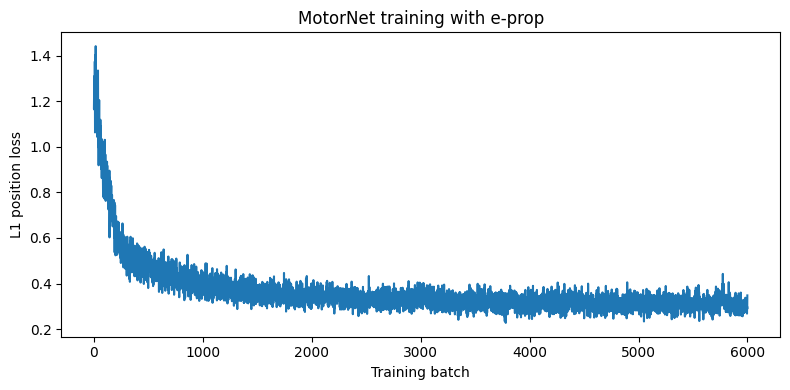

In [ ]:
# ============================================================
# TRAIN
# ============================================================

for batch in range(n_batch):
    hidden = policy.init_hidden(batch_size)
    traces = EligibilityTraces(policy, batch_size)

    obs, info = env.reset(options={"batch_size": batch_size})
    obs = obs.to(device)

    terminated = False
    xy = [info["states"]["fingertip"][:, None, :]]
    tg = [info["goal"][:, None, :]]

    rates = []
    eligibility_in = []
    eligibility_rec = []
    eligibility_bias = []

    while not terminated:
        action, hidden, cache = policy(obs, hidden)

        e_in, e_rec, e_bias = traces.update(cache)

        rates.append(cache["r"])
        eligibility_in.append(e_in)
        eligibility_rec.append(e_rec)
        eligibility_bias.append(e_bias)

        obs, reward, terminated, truncated, info = env.step(action=action)
        obs = obs.to(device)

        xy.append(info["states"]["fingertip"][:, None, :])
        tg.append(info["goal"][:, None, :])

    xy = th.cat(xy, dim=1)
    tg = th.cat(tg, dim=1)
    loss = l1(xy, tg)

    # Exact neuron-specific learning signals dL/dr(t).
    requested = rates + [policy.fc.weight, policy.fc.bias]

    gradients = th.autograd.grad(
        loss,
        requested,
        allow_unused=True,
        retain_graph=False,
    )

    learning_signals = [
        th.zeros_like(r) if g is None else g
        for r, g in zip(rates, gradients[:len(rates)])
    ]

    grad_fc_weight = gradients[-2]
    grad_fc_bias = gradients[-1]

    if grad_fc_weight is None:
        grad_fc_weight = th.zeros_like(policy.fc.weight)

    if grad_fc_bias is None:
        grad_fc_bias = th.zeros_like(policy.fc.bias)


    grad_w_in = th.zeros_like(policy.w_in)
    grad_w_rec = th.zeros_like(policy.w_rec)
    grad_b_rec = th.zeros_like(policy.b_rec)

    for signal, e_in, e_rec, e_bias in zip(
        learning_signals,
        eligibility_in,
        eligibility_rec,
        eligibility_bias,
    ):
        # signal: [batch, hidden]
        # eligibility: [batch, post, pre]
        grad_w_in += th.einsum("bj,bji->ji", signal.detach(), e_in) / batch_size
        grad_w_rec += th.einsum("bj,bji->ji", signal.detach(), e_rec) / batch_size
        grad_b_rec += th.mean(signal.detach() * e_bias, dim=0)

    optimizer.zero_grad(set_to_none=True)

    policy.w_in.grad = grad_w_in
    policy.w_rec.grad = grad_w_rec
    policy.b_rec.grad = grad_b_rec
    policy.fc.weight.grad = grad_fc_weight
    policy.fc.bias.grad = grad_fc_bias

    th.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
    optimizer.step()

    losses.append(loss.item())

    if batch > 0 and batch % interval == 0:
        mean_loss = np.mean(losses[-interval:])
        print(f"Batch {batch}/{n_batch}, mean loss: {mean_loss:.5f}")


# ============================================================
# TRAINING CURVE
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Training batch")
plt.ylabel("L1 position loss")
plt.title("MotorNet training with e-prop")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SAVE
# ============================================================

save_dir = "save"
os.makedirs(save_dir, exist_ok=True)

checkpoint = {
    "model_state_dict": policy.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "losses": losses,
    "hidden_dim": hidden_dim,
    "input_dim": input_dim,
    "output_dim": output_dim,
}

th.save(checkpoint, os.path.join(save_dir, "eprop_policy.pt"))

print("Saved:", os.path.join(save_dir, "eprop_policy.pt"))

Saved: save/eprop_policy.pt


In [ ]:
# ============================================================
# LOAD
# ============================================================
checkpoint = th.load("save/eprop_policy.pt", map_location=device)

policy = EPropPolicy(
    checkpoint["input_dim"],
    checkpoint["hidden_dim"],
    checkpoint["output_dim"],
    device=device,
    dt=dt,
)

policy.load_state_dict(checkpoint["model_state_dict"])
policy.eval()

EPropPolicy(
  (fc): Linear(in_features=32, out_features=4, bias=True)
)

Test L1 loss: 0.29613
Mean endpoint error: 0.02395
Median endpoint error: 0.01639


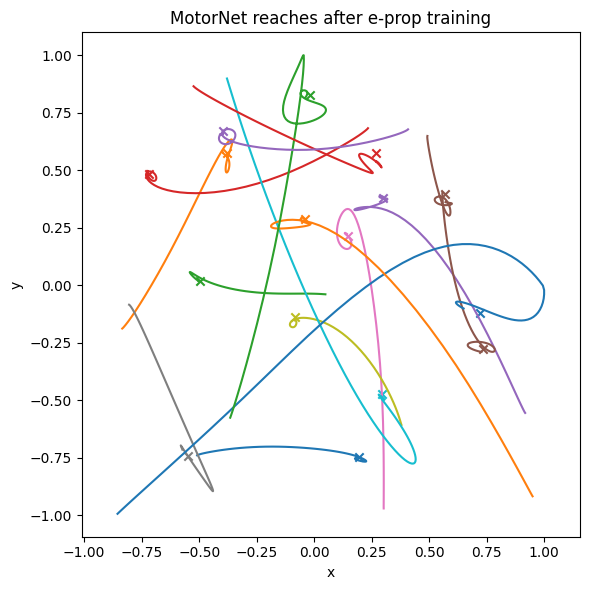

In [ ]:
# ============================================================
# TEST
# ============================================================

policy.eval()

test_batch_size = 32

with th.no_grad():
    hidden = policy.init_hidden(test_batch_size)
    obs, info = env.reset(options={"batch_size": test_batch_size})
    obs = obs.to(device)

    terminated = False
    xy = [info["states"]["fingertip"][:, None, :]]
    tg = [info["goal"][:, None, :]]

    while not terminated:
        action, hidden, _ = policy(obs, hidden)
        obs, reward, terminated, truncated, info = env.step(action=action)
        obs = obs.to(device)

        xy.append(info["states"]["fingertip"][:, None, :])
        tg.append(info["goal"][:, None, :])

    xy = th.cat(xy, dim=1)
    tg = th.cat(tg, dim=1)

    test_loss = l1(xy, tg).item()
    endpoint_error = th.linalg.vector_norm(xy[:, -1] - tg[:, -1], dim=-1)

print(f"Test L1 loss: {test_loss:.5f}")
print(f"Mean endpoint error: {endpoint_error.mean().item():.5f}")
print(f"Median endpoint error: {endpoint_error.median().item():.5f}")


# ============================================================
# PLOT TEST REACHES
# ============================================================

xy_np = xy.cpu().numpy()
tg_np = tg.cpu().numpy()

plt.figure(figsize=(6, 6))

for i in range(min(test_batch_size, 16)):
    plt.plot(xy_np[i, :, 0], xy_np[i, :, 1])
    plt.scatter(tg_np[i, -1, 0], tg_np[i, -1, 1], marker="x")

plt.xlabel("x")
plt.ylabel("y")
plt.title("MotorNet reaches after e-prop training")
plt.axis("equal")
plt.tight_layout()
plt.show()

# MC_Maze — the monkey's own maze, solved by this e-prop

The e-prop network above was trained to reach free-space targets. The macaque it is modelled on
(Churchland, Kaufman & Shenoy; Neural Latents Benchmark **MC_Maze**, DANDI **000128** —
https://dandiarchive.org/dandiset/000128) actually solved a **maze**: it moved a cursor from the
centre to a cued target **through barriers**. This section puts the **same e-prop network** on that
task — the real **108 MC_Maze** puzzles (their true target + barrier geometry) — and gives four tiny,
self-contained functions (in `maze_eprop.py`) to train / evaluate / visualise it. The data downloads
automatically the first time. The objective is the monkey's: reach the target **fast**, with the
**least movement**, **without hitting the walls**. e-prop stays e-prop — leaky units, **no BPTT**,
credit by eligibility traces × learning signals.

In [ ]:
# --- MC_Maze: setup + a fixed 60/20/20 split of the 108 puzzles (auto-downloads the data) ---
import os, sys
sys.path.insert(0, os.getcwd())
import maze_eprop                      # tiny wrapper: same e-prop (EPropPolicy), on the 108 MC-Maze puzzles

train_idx, val_idx, test_idx = maze_eprop.maze_split(seed=0)     # (2) data split, seeded/reproducible
print(f"MC_Maze: {len(train_idx)} train / {len(val_idx)} val / {len(test_idx)} test puzzles (of 108)")

In [ ]:
# --- (1) TRAIN the e-prop network on the maze (tqdm bar + brief loss/val every few episodes) ---
# EPISODES is the only knob; the plain muscle-head e-prop is a from-scratch learner, so more helps.
EPISODES = 4000
policy, history = maze_eprop.train(train_idx, val_idx, test_idx, episodes=EPISODES)

In [ ]:
# --- (3) QUANTITATIVE: success rate, endpoint error (cm), time/episode + per-episode curves ---
# The line-plots show train vs val vs test (and reward) over training — a gap ⇒ over/under-fitting.
_ = maze_eprop.quantitative(policy, train_idx, val_idx, test_idx, history=history)

In [ ]:
# --- (4) QUALITATIVE: a GIF of the e-prop cursor solving one maze (default: a random TEST maze) ---
# Pass maze_id=0..107 to pick a specific one; default draws a random held-out test puzzle.
gif = maze_eprop.qualitative(policy, maze_id=None, test_idx=test_idx)
maze_eprop.show_gif(gif)